# Week 1 EDA - CIC-Bell-DNS-EXF 2021

Exploratory analysis of the CIC-Bell-DNS-EXF 2021 dataset (UNB) before training the Week 2 baseline classifier.

**Goals**

1. Confirm the dataset layout and class balance.
2. Inspect feature distributions per class to identify promising features for the baseline.
3. Surface methodology risks (data leakage, label artifacts) before they bite us in Week 2.
4. Catch data-quality issues (missing values, duplicates, outliers).

## Dataset layout (decoded from the file paths)

| Folder | Contents | Assigned label / scenario |
|---|---|---|
| `Attacks/` | Light exfiltration, 6 payload types | `label="exfil"`, `scenario="light"` |
| `Attacks (1)/` | Heavy exfiltration, 6 payload types | `label="exfil"`, `scenario="heavy"` |
| `Benign/` | Benign captured alongside the light attacks | `label="benign"`, `scenario="benign_matched_light"` |
| `Benign (1)/` | Benign captured alongside the heavy attacks | `label="benign"`, `scenario="benign_matched_heavy"` |
| `Benign (2)/` | Standalone benign (independently captured) | `label="benign"`, `scenario="benign_standalone"` |

Each scenario ships two feature views per source file:

- **stateless** (15 cols) — one row per DNS query. Main input for the Week 2 XGBoost baseline.
- **stateful** (27 cols) — flow-level aggregations (record-type frequencies, distinct-name counts, TTL stats, etc.).

There is no label column in the CSVs - the label is encoded in the file path. The loader below attaches `label`, `scenario`, `payload_type`, `feature_view`, and `source_file` to every row.
    

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")


def find_project_root(start: Path | None = None) -> Path:
    """Walk upward from `start` (or CWD) until pyproject.toml is found."""
    p = (start or Path.cwd()).resolve()
    while p != p.parent:
        if (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("project root (pyproject.toml) not found")


PROJECT_ROOT = find_project_root()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
print(f"Project root: {PROJECT_ROOT}")
print(f"Data root:    {DATA_RAW}")
print(f"Data exists:  {DATA_RAW.exists()}")
    

Project root: C:\Users\greys\code\dns-exfil-detector
Data root:    C:\Users\greys\code\dns-exfil-detector\data\raw
Data exists:  True


## Data loader

Walks `data/raw/`, reads every CSV, and attaches metadata columns derived from the file path. Returns one pandas DataFrame per feature view (stateless or stateful) with all scenarios concatenated.
    

In [2]:
PAYLOAD_TYPES = {"audio", "compressed", "exe", "image", "text", "video"}


def classify_file(path: Path) -> dict[str, str | None]:
    """Derive label/scenario/payload_type/feature_view from a CSV path."""
    rel = path.relative_to(DATA_RAW)
    parts = [p.lower() for p in rel.parts]
    name = rel.name.lower()

    if "stateless" in name:
        feature_view = "stateless"
    elif "stateful" in name:
        feature_view = "stateful"
    else:
        feature_view = "unknown"

    top = parts[0]
    if top == "attacks":
        label, scenario = "exfil", "light"
    elif top == "attacks (1)":
        label, scenario = "exfil", "heavy"
    elif top == "benign":
        label, scenario = "benign", "benign_matched_light"
    elif top == "benign (1)":
        label, scenario = "benign", "benign_matched_heavy"
    elif top == "benign (2)":
        label, scenario = "benign", "benign_standalone"
    else:
        label, scenario = "unknown", "unknown"

    payload_type: str | None = None
    for ptype in PAYLOAD_TYPES:
        if f"_{ptype}." in name:
            payload_type = ptype
            break

    return {
        "label": label,
        "scenario": scenario,
        "payload_type": payload_type,
        "feature_view": feature_view,
        "source_file": str(rel).replace("\\", "/"),
    }


def load_csvs(feature_view: str) -> pd.DataFrame:
    """Load all CSVs of a given feature_view, attach metadata, concatenate."""
    dfs = []
    for path in sorted(DATA_RAW.rglob("*.csv")):
        meta = classify_file(path)
        if meta["feature_view"] != feature_view:
            continue
        df = pd.read_csv(path, low_memory=False)
        for k, v in meta.items():
            df[k] = v
        dfs.append(df)
    if not dfs:
        raise RuntimeError(f"no CSVs found for feature_view={feature_view!r}")
    return pd.concat(dfs, ignore_index=True)


stateless = load_csvs("stateless")
stateful = load_csvs("stateful")
print(f"stateless: {len(stateless):>8,} rows x {len(stateless.columns):>2} columns")
print(f"stateful:  {len(stateful):>8,} rows x {len(stateful.columns):>2} columns")
    

stateless:  757,211 rows x 20 columns
stateful:   262,105 rows x 32 columns


## Schema overview

Confirm the column names UNB shipped (some of them were truncated in the verifier output).
    

In [3]:
METADATA_COLS = {"label", "scenario", "payload_type", "feature_view", "source_file"}

print("=== STATELESS columns (15 data + 5 metadata) ===")
for c in stateless.columns:
    tag = " [meta]" if c in METADATA_COLS else ""
    print(f"  {c}{tag}")

print()
print("=== STATEFUL columns (27 data + 5 metadata) ===")
for c in stateful.columns:
    tag = " [meta]" if c in METADATA_COLS else ""
    print(f"  {c}{tag}")
    

=== STATELESS columns (15 data + 5 metadata) ===
  timestamp
  FQDN_count
  subdomain_length
  upper
  lower
  numeric
  entropy
  special
  labels
  labels_max
  labels_average
  longest_word
  sld
  len
  subdomain
  label [meta]
  scenario [meta]
  payload_type [meta]
  feature_view [meta]
  source_file [meta]

=== STATEFUL columns (27 data + 5 metadata) ===
  rr
  A_frequency
  NS_frequency
  CNAME_frequency
  SOA_frequency
  NULL_frequency
  PTR_frequency
  HINFO_frequency
  MX_frequency
  TXT_frequency
  AAAA_frequency
  SRV_frequency
  OPT_frequency
  rr_type
  rr_count
  rr_name_entropy
  rr_name_length
  distinct_ns
  distinct_ip
  unique_country
  unique_asn
  distinct_domains
  reverse_dns
  a_records
  unique_ttl
  ttl_mean
  ttl_variance
  label [meta]
  scenario [meta]
  payload_type [meta]
  feature_view [meta]
  source_file [meta]


## Class and scenario distribution

How balanced is the dataset, and how much of each scenario do we have to work with?
    

In [4]:
def show_distribution(df: pd.DataFrame, name: str) -> None:
    print(f"### {name} ###")
    print()
    print("label:")
    print(df["label"].value_counts().to_string())
    print()
    print("scenario:")
    print(df["scenario"].value_counts().to_string())
    if (df["label"] == "exfil").any():
        print()
        print("payload_type (exfil rows only):")
        print(df.loc[df["label"] == "exfil", "payload_type"].value_counts().to_string())
    print()


show_distribution(stateless, "Stateless (per-query)")
show_distribution(stateful, "Stateful (aggregated)")
    

### Stateless (per-query) ###

label:
label
benign    462858
exfil     294353

scenario:
scenario
heavy                   251670
benign_standalone       221073
benign_matched_heavy    181694
benign_matched_light     60091
light                    42683

payload_type (exfil rows only):
payload_type
text          74581
audio         53413
compressed    45987
video         42383
exe           41079
image         36910

### Stateful (aggregated) ###

label:


label
benign    178782
exfil      83323

scenario:
scenario
benign_standalone       86998
heavy                   72028
benign_matched_heavy    69016
benign_matched_light    22768
light                   11295

payload_type (exfil rows only):
payload_type
text          19837
audio         14981
compressed    13328
video         12142
exe           11816
image         11219



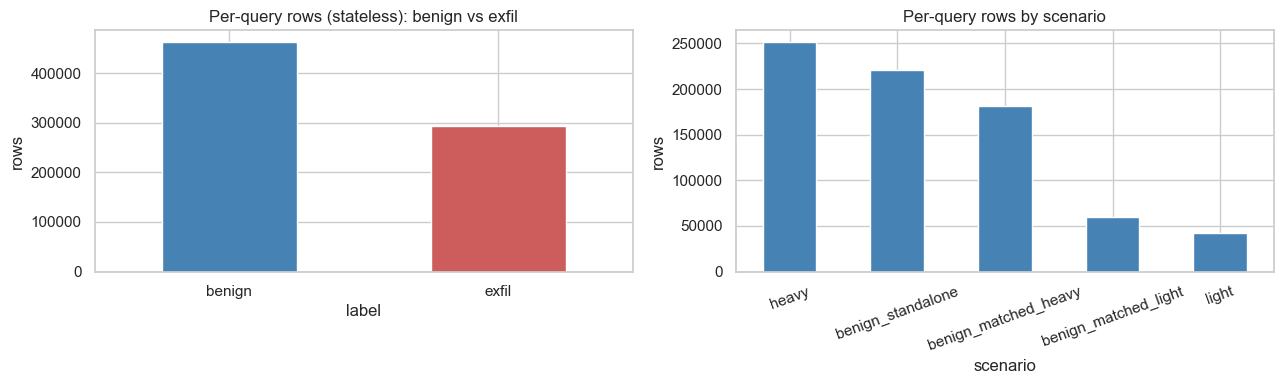

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

stateless["label"].value_counts().plot.bar(
    ax=axes[0], color=["steelblue", "indianred"]
)
axes[0].set_title("Per-query rows (stateless): benign vs exfil")
axes[0].set_ylabel("rows")
axes[0].tick_params(axis="x", labelrotation=0)

stateless["scenario"].value_counts().plot.bar(ax=axes[1], color="steelblue")
axes[1].set_title("Per-query rows by scenario")
axes[1].set_ylabel("rows")
axes[1].tick_params(axis="x", labelrotation=20)

plt.tight_layout()
plt.show()
    

## Per-query feature distributions (stateless)

These are the features the Week 2 XGBoost baseline will consume. If a feature's benign and exfil distributions look meaningfully different, it's a candidate. If they look identical, it isn't (or it carries leakage that we'll catch later).

The histograms are clipped at the 99th percentile to keep extreme outliers from squashing the visible range.
    

In [6]:
def feature_hist_by_label(
    df: pd.DataFrame, feature: str, ax=None, clip_q: float = 0.99, bins: int = 60
) -> None:
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))
    for lbl, color in [("benign", "steelblue"), ("exfil", "indianred")]:
        data = df.loc[df["label"] == lbl, feature].dropna()
        if not len(data):
            continue
        cap = data.quantile(clip_q)
        ax.hist(
            data.clip(upper=cap),
            bins=bins,
            alpha=0.55,
            density=True,
            color=color,
            label=f"{lbl} (n={len(data):,})",
        )
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("density")
    ax.legend()


numeric_stateless = [
    c for c in stateless.columns
    if c not in METADATA_COLS and pd.api.types.is_numeric_dtype(stateless[c])
]
print(f"Numeric stateless features: {numeric_stateless}")
    

Numeric stateless features: ['FQDN_count', 'subdomain_length', 'upper', 'lower', 'numeric', 'entropy', 'special', 'labels', 'labels_max', 'labels_average', 'len', 'subdomain']


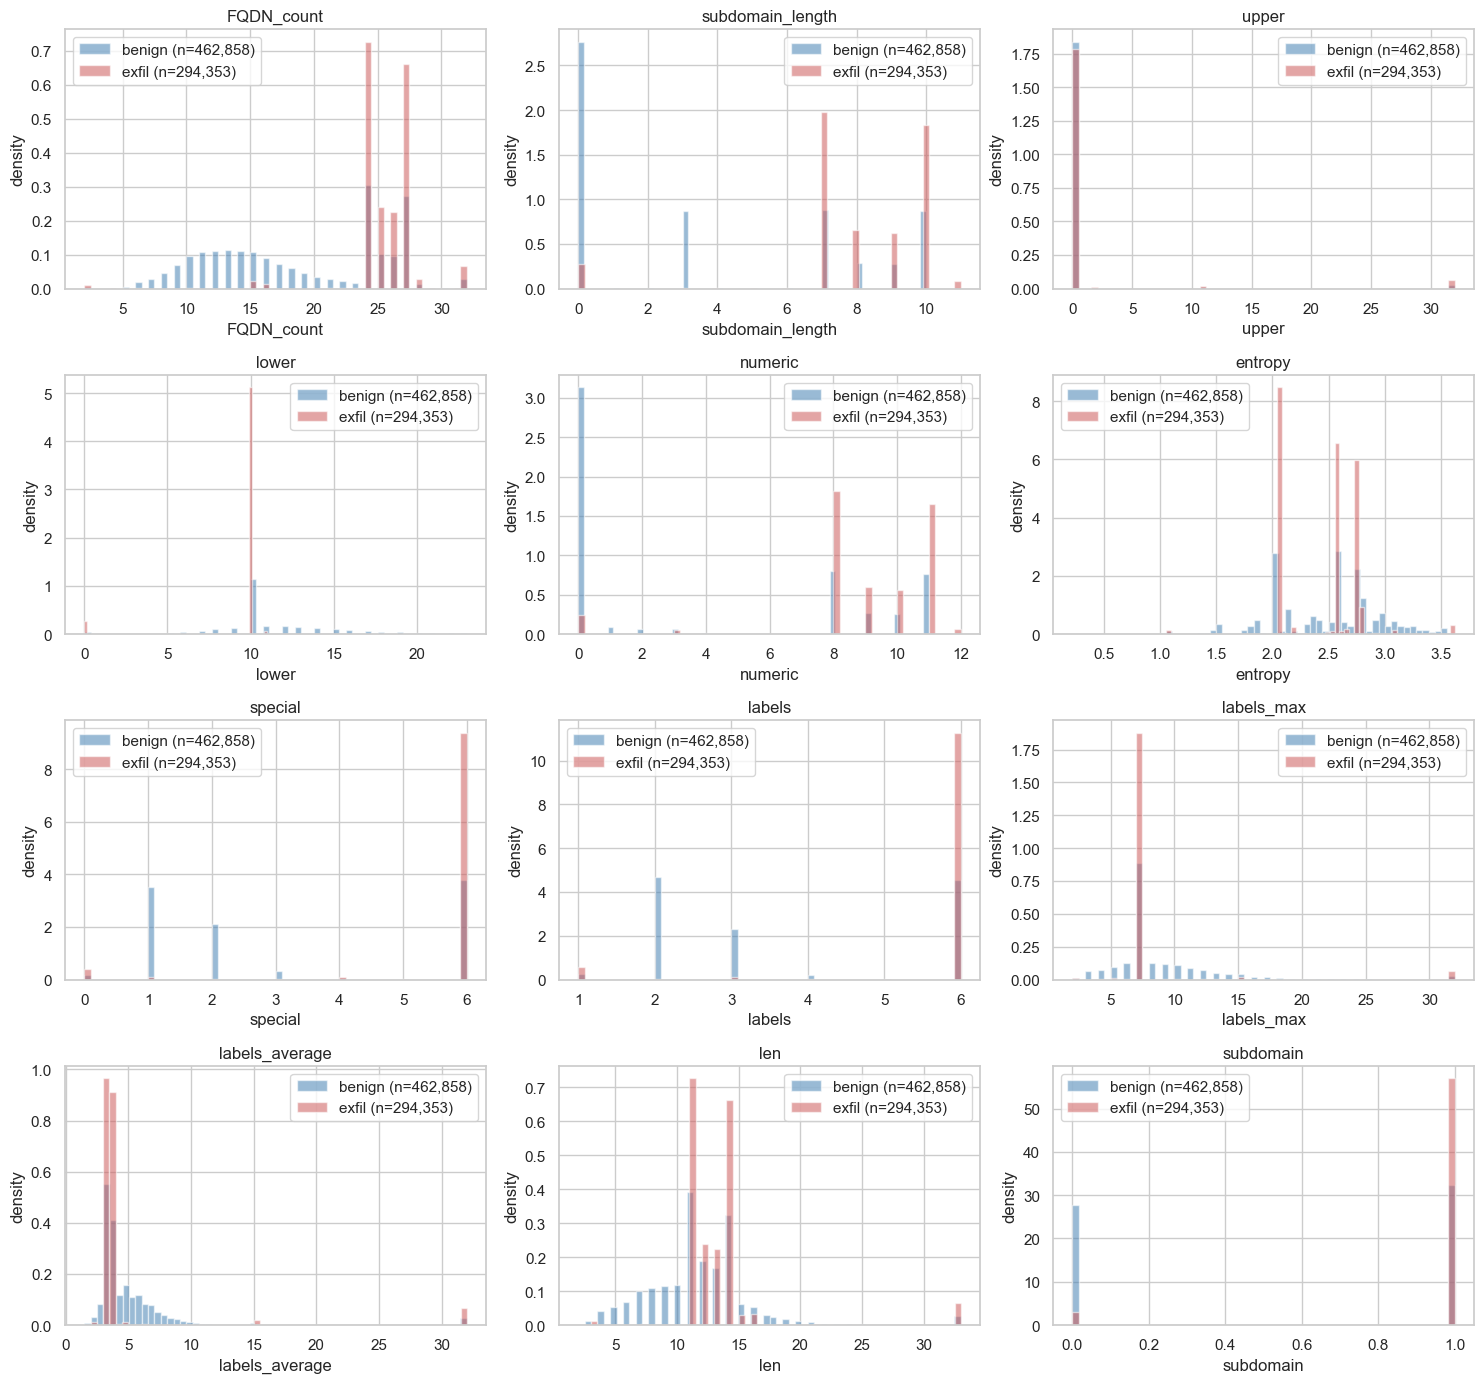

In [7]:
import math

cols_to_plot = numeric_stateless
n = len(cols_to_plot)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes_flat = list(axes.flat) if nrows > 1 else list(axes)
for ax, feat in zip(axes_flat, cols_to_plot):
    feature_hist_by_label(stateless, feat, ax=ax)
for ax in axes_flat[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()
    

## Character-class proportions (stateless)

The stateless schema gives us raw counts of `upper`, `lower`, `numeric`, and `special` characters per query name. Looking at the *proportions* (each count divided by the total characters in the name) is more useful than the raw counts: it cancels out length and exposes whether the *composition* of a query name differs by class.

A query name encoding base64-style smuggled bytes will skew toward `numeric` + `special` + mixed case. A name that's a normal hostname will be mostly `lower`.
    

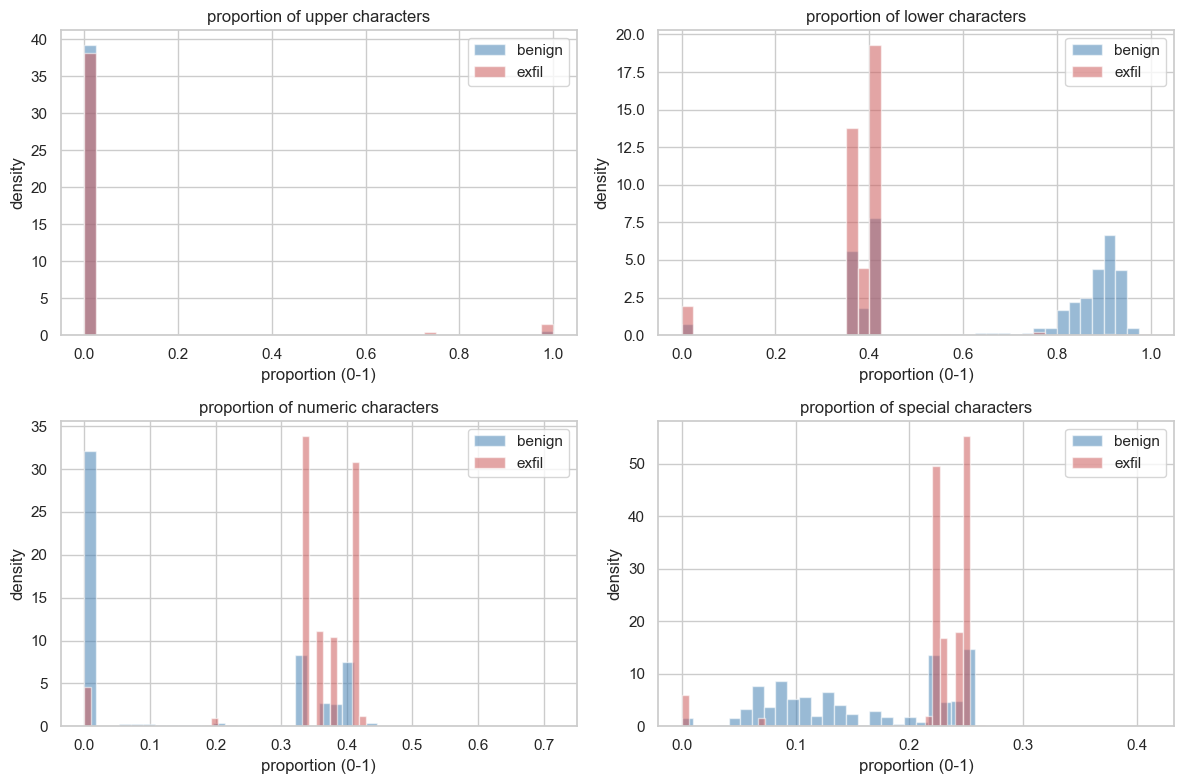

In [8]:
char_cols = [c for c in ["upper", "lower", "numeric", "special"] if c in stateless.columns]

if char_cols:
    char_data = stateless[char_cols].astype(float)
    totals = char_data.sum(axis=1).replace(0, np.nan)
    proportions = char_data.div(totals, axis=0)
    proportions["label"] = stateless["label"].values

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, col in zip(axes.flat, char_cols):
        for lbl, color in [("benign", "steelblue"), ("exfil", "indianred")]:
            data = proportions.loc[proportions["label"] == lbl, col].dropna()
            ax.hist(data, bins=40, alpha=0.55, density=True, color=color, label=lbl)
        ax.set_title(f"proportion of {col} characters")
        ax.set_xlabel("proportion (0-1)")
        ax.set_ylabel("density")
        ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("(no char-class columns found in stateless schema)")
    

## Stateful: rr_type distribution by class

The stateful files have an `rr_type` column whose values look like Python sets stringified - `{'PTR'}`, `{'A'}`, `set()`. We collapse each into a single representative type and look at the per-class distribution.

Heavy use of unusual types (`NULL`, `TXT`, `HINFO`) on the exfil side would be a signal, since DNS tunneling tools often use those to carry larger payloads.
    

In [9]:
def parse_rr_type(s: object) -> str:
    if not isinstance(s, str):
        return "unknown"
    s = s.strip()
    if s in {"set()", "{}", ""}:
        return "none"
    inner = s.strip("{}").replace("'", "").replace('"', "")
    types = sorted({t.strip() for t in inner.split(",") if t.strip()})
    if not types:
        return "none"
    if len(types) == 1:
        return types[0]
    return "mixed(" + "|".join(types) + ")" if len(types) <= 3 else "mixed(many)"


if "rr_type" in stateful.columns:
    stateful["rr_type_clean"] = stateful["rr_type"].apply(parse_rr_type)

    crosstab = pd.crosstab(
        stateful["rr_type_clean"], stateful["label"], normalize="columns"
    )
    crosstab = crosstab.sort_values("exfil", ascending=False).round(4) * 100
    crosstab.columns = [f"{c} %" for c in crosstab.columns]
    print("=== rr_type share within each class (percent) ===")
    print(crosstab.to_string())
else:
    print("(no rr_type column found)")
    

=== rr_type share within each class (percent) ===
               benign %  exfil %
rr_type_clean                   
PTR               27.39    93.75
None               1.05     3.32
none               0.61     1.91
A                 70.95     1.02
TXT                0.00     0.00
mixed(A|AAAA)      0.00     0.00


## Stateful: numeric feature distributions

The stateful view has ~25 numeric features. We plot every one of them by class (clipped at 99th percentile). What we're looking for:

- Features with clearly different distributions for benign vs exfil → candidates for the model
- Features that are zero or near-zero across both classes → probably useless
- Features that are *perfectly separated* (the two histograms don't overlap at all) → leakage candidates that warrant investigation
    

In [10]:
numeric_stateful = [
    c for c in stateful.columns
    if c not in METADATA_COLS and c != "rr_type_clean"
    and pd.api.types.is_numeric_dtype(stateful[c])
]
print(f"Numeric stateful features ({len(numeric_stateful)}): {numeric_stateful}")
    

Numeric stateful features (20): ['rr', 'A_frequency', 'NS_frequency', 'CNAME_frequency', 'SOA_frequency', 'NULL_frequency', 'PTR_frequency', 'HINFO_frequency', 'MX_frequency', 'TXT_frequency', 'AAAA_frequency', 'SRV_frequency', 'OPT_frequency', 'rr_count', 'rr_name_entropy', 'rr_name_length', 'distinct_ns', 'a_records', 'ttl_mean', 'ttl_variance']


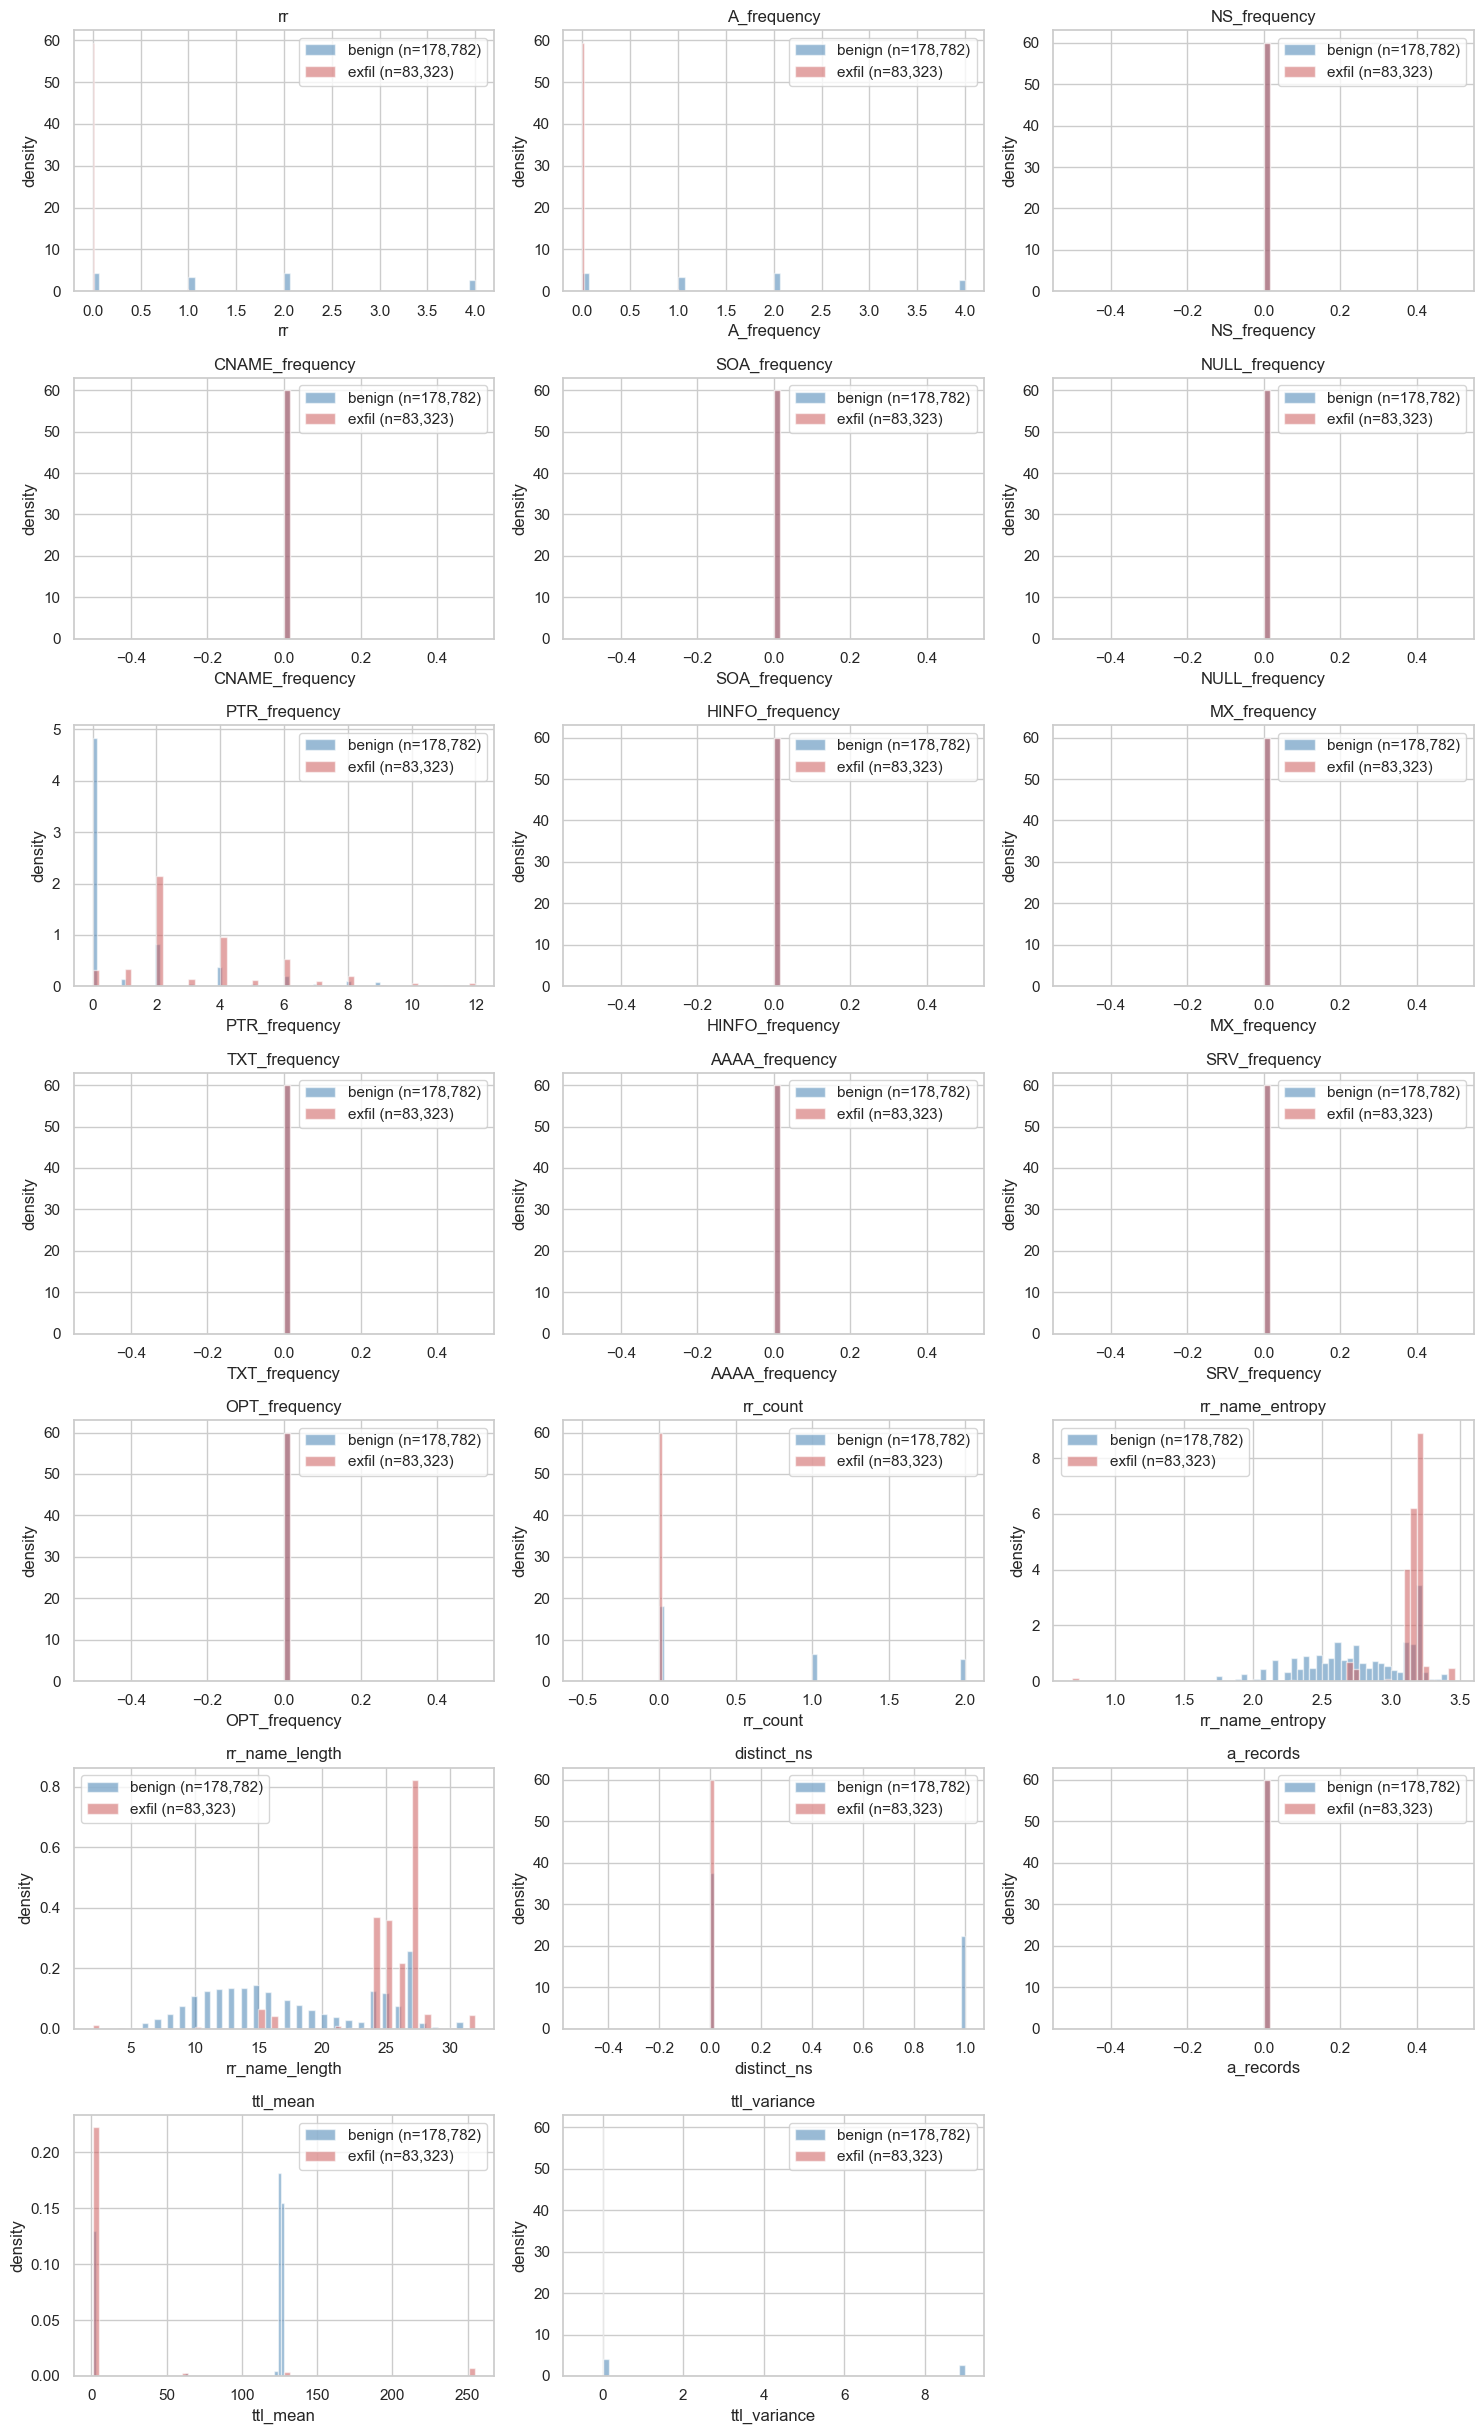

In [11]:
n = len(numeric_stateful)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes_flat = list(axes.flat) if nrows > 1 else list(axes)
for ax, feat in zip(axes_flat, numeric_stateful):
    feature_hist_by_label(stateful, feat, ax=ax)
for ax in axes_flat[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()
    

## Leakage smell test 1: matched-benign vs standalone-benign

The dataset has THREE flavors of benign traffic:

- `benign_matched_light` (captured alongside light attacks)
- `benign_matched_heavy` (captured alongside heavy attacks)
- `benign_standalone` (captured independently)

If these three look statistically the same, all benign data is interchangeable. If they look DIFFERENT, the matched benigns may be contaminated with testbed-specific artifacts (same network conditions as the attacks, same time-of-day, same resolver, etc.) - and training on them risks learning the testbed rather than the attack signal.

We compare them on the same per-query features.
    

In [12]:
benign_only = stateless[stateless["label"] == "benign"]
key_features = [
    f for f in ["subdomain_length", "entropy", "FQDN_count"]
    if f in stateless.columns
]
if not key_features:
    key_features = [c for c in numeric_stateless[:3]]

print("=== Mean of key features by benign scenario ===")
print(benign_only.groupby("scenario")[key_features].mean().round(4))
print()
print("=== Median of key features by benign scenario ===")
print(benign_only.groupby("scenario")[key_features].median().round(4))
print()
print("=== Sample size per scenario ===")
print(benign_only.groupby("scenario").size())
    

=== Mean of key features by benign scenario ===
                      subdomain_length  entropy  FQDN_count
scenario                                                   
benign_matched_heavy            3.7058   2.5372     18.7144
benign_matched_light            3.6371   2.5374     18.6067
benign_standalone               3.8601   2.4731     18.4539

=== Median of key features by benign scenario ===
                      subdomain_length  entropy  FQDN_count
scenario                                                   
benign_matched_heavy               3.0   2.5704        18.0
benign_matched_light               3.0   2.5704        18.0
benign_standalone                  3.0   2.5704        18.0

=== Sample size per scenario ===
scenario
benign_matched_heavy    181694
benign_matched_light     60091
benign_standalone       221073
dtype: int64


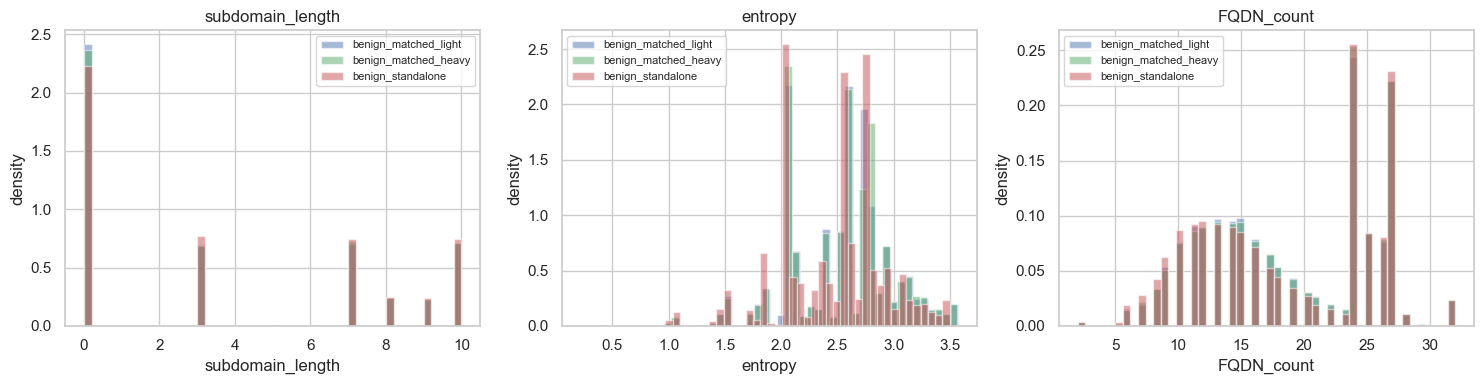

In [13]:
benign_scenarios = ["benign_matched_light", "benign_matched_heavy", "benign_standalone"]
palette = {
    "benign_matched_light": "#4C72B0",
    "benign_matched_heavy": "#55A868",
    "benign_standalone": "#C44E52",
}

fig, axes = plt.subplots(1, len(key_features), figsize=(5 * len(key_features), 4))
if len(key_features) == 1:
    axes = [axes]
for ax, feat in zip(axes, key_features):
    for sc in benign_scenarios:
        data = benign_only.loc[benign_only["scenario"] == sc, feat].dropna()
        if not len(data):
            continue
        cap = data.quantile(0.99)
        ax.hist(
            data.clip(upper=cap),
            bins=50, alpha=0.5, density=True, color=palette[sc], label=sc,
        )
    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.set_ylabel("density")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
    

## Leakage smell test 2: single-feature AUC

For each numeric feature, fit a trivial "use this feature alone as the classifier" model and compute its ROC AUC. Any feature with AUC > ~0.99 is suspicious: real signals usually max out around 0.85-0.95 on their own, and the rest of the lift comes from combinations.

A near-perfect single-feature AUC usually means the feature directly encodes the label (capture artifact, source-IP-leak, or similar), not actual attack behavior.
    

In [14]:
from sklearn.metrics import roc_auc_score


def single_feature_aucs(df: pd.DataFrame, numeric_cols: list[str]) -> pd.DataFrame:
    y = (df["label"] == "exfil").astype(int).to_numpy()
    rows = []
    for c in numeric_cols:
        x = df[c]
        if x.isna().all():
            continue
        x = x.fillna(x.median())
        try:
            auc = roc_auc_score(y, x)
        except Exception:
            continue
        rows.append((c, max(auc, 1 - auc)))
    return pd.DataFrame(rows, columns=["feature", "single_feature_auc"]).sort_values(
        "single_feature_auc", ascending=False
    )


print("=== Stateless single-feature AUCs ===")
print(single_feature_aucs(stateless, numeric_stateless).to_string(index=False))
print()
print("=== Stateful single-feature AUCs ===")
print(single_feature_aucs(stateful, numeric_stateful).to_string(index=False))
    

=== Stateless single-feature AUCs ===


         feature  single_feature_auc
      FQDN_count            0.782058
         numeric            0.781600
subdomain_length            0.776035
         special            0.769624
          labels            0.766978
       subdomain            0.705482
  labels_average            0.692760
           lower            0.621956
             len            0.620035
      labels_max            0.573933
         entropy            0.563932
           upper            0.514355

=== Stateful single-feature AUCs ===


        feature  single_feature_auc
    A_frequency            0.851138
             rr            0.851136
  PTR_frequency            0.830384
       ttl_mean            0.824169
 rr_name_length            0.819572
rr_name_entropy            0.812426
       rr_count            0.698269
   ttl_variance            0.694297
    distinct_ns            0.686475
  TXT_frequency            0.500012
 AAAA_frequency            0.500000
   NS_frequency            0.500000
CNAME_frequency            0.500000
  SRV_frequency            0.500000
 NULL_frequency            0.500000
HINFO_frequency            0.500000
  SOA_frequency            0.500000
   MX_frequency            0.500000
  OPT_frequency            0.500000
      a_records            0.500000


## Data quality

Missing values per column, duplicate-row count, and a quick check for impossible / out-of-range values.
    

In [15]:
def report_missing(df: pd.DataFrame, name: str) -> None:
    miss = df.isna().sum()
    miss = miss[miss > 0]
    print(f"=== Missing values, {name} ===")
    if miss.empty:
        print("  (none)")
    else:
        print(miss.sort_values(ascending=False).to_string())
    print()


report_missing(stateless, "stateless")
report_missing(stateful, "stateful")

print("=== Duplicate rows (ignoring metadata) ===")
data_cols_stateless = [c for c in stateless.columns if c not in METADATA_COLS]
data_cols_stateful = [c for c in stateful.columns if c not in METADATA_COLS]
dup_stateless = stateless[data_cols_stateless].astype(str).duplicated().sum()
dup_stateful = stateful[data_cols_stateful].astype(str).duplicated().sum()
print(f"  stateless: {dup_stateless:>8,} / {len(stateless):,} rows  ({100 * dup_stateless / len(stateless):.2f}%)")
print(f"  stateful:  {dup_stateful:>8,} / {len(stateful):,} rows  ({100 * dup_stateful / len(stateful):.2f}%)")
    

=== Missing values, stateless ===
payload_type    462858
longest_word        31

=== Missing values, stateful ===
payload_type    178782

=== Duplicate rows (ignoring metadata) ===


  stateless:      526 / 757,211 rows  (0.07%)
  stateful:   148,760 / 262,105 rows  (56.76%)


In [16]:
print("=== Numeric stateless sanity (range check) ===")
desc = stateless[numeric_stateless].describe().T[["min", "max", "mean", "std"]].round(3)
print(desc.to_string())
print()
print("Specific impossibility checks:")
if "entropy" in stateless.columns:
    bad = (stateless["entropy"] < 0).sum()
    print(f"  entropy < 0: {bad:,} rows  (entropy is always >= 0; nonzero = data bug)")
if "subdomain_length" in stateless.columns:
    bad = (stateless["subdomain_length"] < 0).sum()
    print(f"  subdomain_length < 0: {bad:,} rows  (length is always >= 0)")
if "FQDN_count" in stateless.columns:
    bad = (stateless["FQDN_count"] < 0).sum()
    print(f"  FQDN_count < 0: {bad:,} rows")
    

=== Numeric stateless sanity (range check) ===


                    min     max    mean    std
FQDN_count        2.000  36.000  21.209  6.499
subdomain_length  0.000  29.000   5.446  4.057
upper             0.000  32.000   0.740  4.629
lower             0.000  34.000  10.577  3.369
numeric           0.000  14.000   5.735  4.700
entropy           0.219   4.368   2.482  0.427
special           0.000   8.000   4.157  2.297
labels            1.000   7.000   4.503  1.869
labels_max        2.000  32.000   8.225  4.314
labels_average    1.500  32.000   4.831  4.321
len               2.000  35.000  12.262  4.228
subdomain         0.000   1.000   0.699  0.459

Specific impossibility checks:
  entropy < 0: 0 rows  (entropy is always >= 0; nonzero = data bug)
  subdomain_length < 0: 0 rows  (length is always >= 0)
  FQDN_count < 0: 0 rows


## Summary of findings

*Filled in after running the notebook; see `docs/week1_findings.md` for the polished one-page write-up.*

### What looks promising for the Week 2 baseline
- (filled in based on per-class distributions and single-feature AUCs)

### Leakage risks identified
- (filled in based on the smell tests)

### Data quality notes
- (filled in based on missing/duplicate/range checks)

### Open questions for Week 2
- (filled in)
    